# Objective 3: Local Goodness for Spatial Data

This notebook trains locally connected (no weight-sharing) FF models on jittered MNIST,
and compares local-block architectural choices.

In [1]:
import importlib
import sys
from pathlib import Path

import pandas as pd
import torch

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

import ff_research.experiments as experiments
import ff_research.utils as utils

importlib.reload(utils)
importlib.reload(experiments)

from ff_research.experiments import run_goodness_sweep, run_local_spatial_experiment
from ff_research.utils import seed_everything

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [2]:
seed_everything(42)

In [3]:
spatial_setups = [
    {
        "name": "coarse_blocks",
        "activation": "relu",
        "goodness": "sum_sq",
        "layer_specs": [
            {"kernel_size": 7, "stride": 3, "out_channels": 32},
            {"kernel_size": 2, "stride": 1, "out_channels": 64},
        ],
    },
    {
        "name": "finer_blocks",
        "activation": "relu",
        "goodness": "sum_sq",
        "layer_specs": [
            {"kernel_size": 5, "stride": 2, "out_channels": 32},
            {"kernel_size": 3, "stride": 1, "out_channels": 64},
        ],
    },
    {
        "name": "unsquared_goodness",
        "activation": "relu",
        "goodness": "sum_abs",
        "layer_specs": [
            {"kernel_size": 7, "stride": 3, "out_channels": 32},
            {"kernel_size": 2, "stride": 1, "out_channels": 64},
        ],
    },
    {
        "name": "student_t_activation",
        "activation": "student_t_nll_df3",
        "goodness": "sum_sq",
        "layer_specs": [
            {"kernel_size": 7, "stride": 3, "out_channels": 32},
            {"kernel_size": 2, "stride": 1, "out_channels": 64},
        ],
    },
]
len(spatial_setups)

4

In [4]:
# Quick verification pass
quick = run_local_spatial_experiment(
    activation_name="relu",
    goodness_name="sum_sq",
    layer_specs=spatial_setups[0]["layer_specs"],
    epochs=1,
    batch_size=128,
    train_subset=3000,
    test_subset=1000,
    jitter=True,
    max_train_batches=8,
    device=device,
    seed=42,
)
quick

{'epoch': 1,
 'train_loss': 2.0433173775672913,
 'train_pos_goodness': 0.32291896105743945,
 'train_neg_goodness': 0.32308587804436684,
 'goodness_margin': -0.0001669169869273901,
 'test_accuracy': 0.045,
 'test_error': 0.955}

In [5]:
# Full Objective 3 comparison
rows = []
for setup in spatial_setups:
    metrics = run_local_spatial_experiment(
        activation_name=setup["activation"],
        goodness_name=setup["goodness"],
        layer_specs=setup["layer_specs"],
        epochs=10,
        batch_size=128,
        train_subset=30000,
        test_subset=10000,
        jitter=True,
        max_train_batches=None,
        max_eval_batches=None,
        device=device,
        seed=42,
    )
    row = {"setup": setup["name"], **metrics}
    rows.append(row)

obj3_results = pd.DataFrame(rows).sort_values("test_accuracy", ascending=False).reset_index(drop=True)
obj3_results

,setup,epoch,train_loss,train_pos_goodness,train_neg_goodness,goodness_margin,test_accuracy,test_error
0,unsquared_goodness,10,1.335932,1.094110,0.950601,0.143510,0.5781,0.4219
1,student_t_activation,10,1.337863,2.092228,1.931047,0.161182,0.5159,0.4841
2,finer_blocks,10,1.363065,2.039513,1.966984,0.072529,0.4870,0.5130
3,coarse_blocks,10,1.352231,2.060941,1.947516,0.113425,0.4453,0.5547


In [6]:
obj3_results.to_csv(ROOT / "results_objective3_local_spatial.csv", index=False)
obj3_results

,setup,epoch,train_loss,train_pos_goodness,train_neg_goodness,goodness_margin,test_accuracy,test_error
0,unsquared_goodness,10,1.335932,1.094110,0.950601,0.143510,0.5781,0.4219
1,student_t_activation,10,1.337863,2.092228,1.931047,0.161182,0.5159,0.4841
2,finer_blocks,10,1.363065,2.039513,1.966984,0.072529,0.4870,0.5130
3,coarse_blocks,10,1.352231,2.060941,1.947516,0.113425,0.4453,0.5547


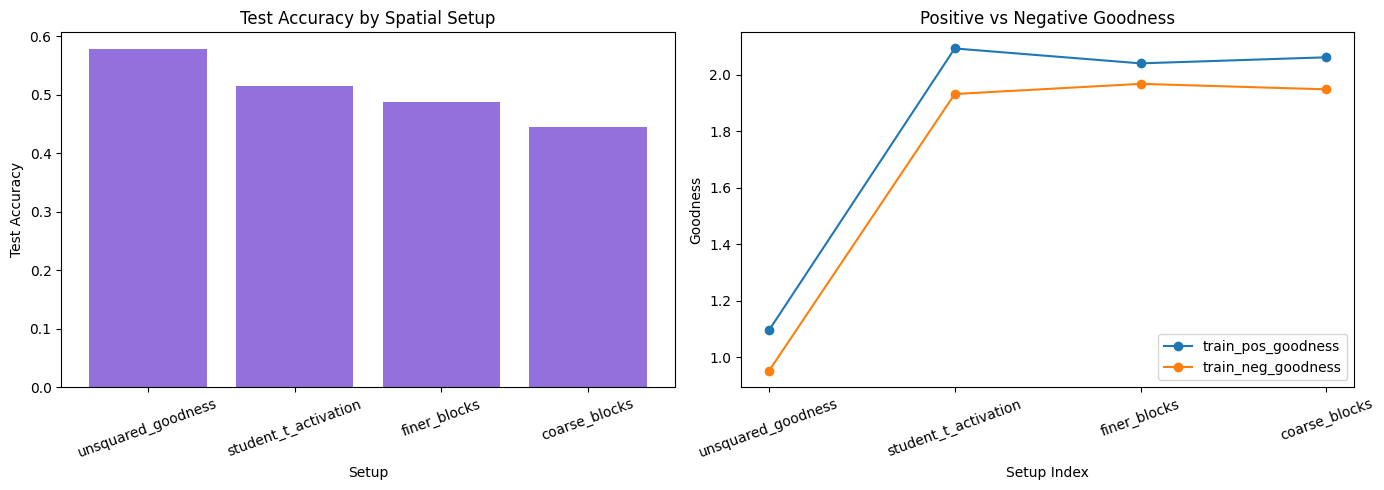

,setup,test_accuracy,test_error,train_loss,train_pos_goodness,train_neg_goodness,goodness_margin
0,unsquared_goodness,0.5781,0.4219,1.335932,1.094110,0.950601,0.143510
1,student_t_activation,0.5159,0.4841,1.337863,2.092228,1.931047,0.161182
2,finer_blocks,0.4870,0.5130,1.363065,2.039513,1.966984,0.072529
3,coarse_blocks,0.4453,0.5547,1.352231,2.060941,1.947516,0.113425


In [7]:
import matplotlib.pyplot as plt

plot_df = obj3_results.copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(plot_df["setup"], plot_df["test_accuracy"], color="mediumpurple")
axes[0].set_title("Test Accuracy by Spatial Setup")
axes[0].set_xlabel("Setup")
axes[0].set_ylabel("Test Accuracy")
axes[0].tick_params(axis="x", rotation=20)

x = range(len(plot_df))
axes[1].plot(x, plot_df["train_pos_goodness"], marker="o", label="train_pos_goodness")
axes[1].plot(x, plot_df["train_neg_goodness"], marker="o", label="train_neg_goodness")
axes[1].set_title("Positive vs Negative Goodness")
axes[1].set_xlabel("Setup Index")
axes[1].set_ylabel("Goodness")
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(plot_df["setup"], rotation=20)
axes[1].legend()

plt.tight_layout()
plt.show()

plot_df[["setup", "test_accuracy", "test_error", "train_loss", "train_pos_goodness", "train_neg_goodness", "goodness_margin"]]

## Visualization and Analysis

Objective 3 tracks training goodness signals, so the plots focus on goodness margin and positive/negative goodness trends.

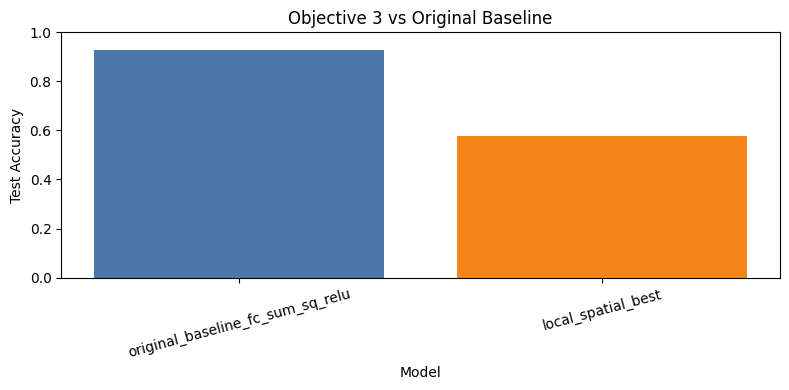

In [8]:
# Baseline (original FF: sum_sq + relu) vs best local-spatial model
if "test_accuracy" not in obj3_results.columns:
    raise ValueError("Please rerun Cell 6 first so obj3_results includes test_accuracy/test_error.")

baseline_row = run_goodness_sweep(
    goodness_names=["sum_sq"],
    activation_name="relu",
    hidden_dims=(512, 512, 512),
    epochs=10,
    batch_size=128,
    train_subset=30000,
    test_subset=10000,
    max_train_batches=None,
    max_eval_batches=None,
    device=device,
    seed=42,
)[0]

best_local = obj3_results.sort_values("test_accuracy", ascending=False).iloc[0]

comparison_df = pd.DataFrame(
    [
        {
            "model": "original_baseline_fc_sum_sq_relu",
            "setup": "sum_sq + relu",
            "test_accuracy": baseline_row["test_accuracy"],
            "test_error": baseline_row["test_error"],
            "train_loss": baseline_row["train_loss"],
            "goodness_margin": None,
        },
        {
            "model": "local_spatial_best",
            "setup": best_local["setup"],
            "test_accuracy": best_local["test_accuracy"],
            "test_error": best_local["test_error"],
            "train_loss": best_local["train_loss"],
            "goodness_margin": best_local["goodness_margin"],
        },
    ]
).sort_values("test_accuracy", ascending=False).reset_index(drop=True)

comparison_df["accuracy_delta_vs_baseline"] = (
    comparison_df["test_accuracy"] - baseline_row["test_accuracy"]
)
comparison_df

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(comparison_df["model"], comparison_df["test_accuracy"], color=["#4C78A8", "#F58518"])
ax.set_title("Objective 3 vs Original Baseline")
ax.set_ylabel("Test Accuracy")
ax.set_xlabel("Model")
ax.set_ylim(0, 1)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()